In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
DATA_DIR = Path('../data')

VERTICES   = [10, 50, 100, 500, 1000]
DENSITIES  = [25, 50, 75, 100]
ALGOS      = ['dijkstra', 'bellman_ford']
GRAPH_TYPES = ['list', 'matrix']

records = []

for algo in ALGOS:
    for g_type in GRAPH_TYPES:
        for v in VERTICES:
            for d in DENSITIES:
                fname = DATA_DIR / f'{v}_{d}_{algo}_{g_type}.csv'
                if not fname.exists():
                    print(f'Brak pliku: {fname}')
                    continue
                df = pd.read_csv(fname)
                avg_ns = df['ns'].mean()
                records.append({
                    'algo':       algo,
                    'graph_type': g_type,
                    'vertices':   v,
                    'density':    d,
                    'avg_ns':     avg_ns,
                    'avg_us':     avg_ns / 1_000,
                    'avg_ms':     avg_ns / 1_000_000,
                })

df_all = pd.DataFrame(records)
print(df_all)

            algo graph_type  vertices  density        avg_ns        avg_us  \
0       dijkstra       list        10       25  2.569350e+03  2.569350e+00   
1       dijkstra       list        10       50  4.721120e+03  4.721120e+00   
2       dijkstra       list        10       75  4.876390e+03  4.876390e+00   
3       dijkstra       list        10      100  5.504880e+03  5.504880e+00   
4       dijkstra       list        50       25  3.759290e+04  3.759290e+01   
..           ...        ...       ...      ...           ...           ...   
75  bellman_ford     matrix       500      100  2.256237e+09  2.256237e+06   
76  bellman_ford     matrix      1000       25  8.517761e+09  8.517761e+06   
77  bellman_ford     matrix      1000       50  1.455780e+10  1.455780e+07   
78  bellman_ford     matrix      1000       75  1.599194e+10  1.599194e+07   
79  bellman_ford     matrix      1000      100  1.696305e+10  1.696305e+07   

          avg_ms  
0       0.002569  
1       0.004721  
2     

In [3]:
for algo in ALGOS:
    for g_type in GRAPH_TYPES:
        subset = df_all[(df_all.algo == algo) & (df_all.graph_type == g_type)]
        pivot = subset.pivot(index='vertices', columns='density', values='avg_us')
        pivot.columns = [f'{d}%' for d in pivot.columns]
        print(f'\n=== {algo.upper()} | {g_type} ===')
        print(pivot.to_string(float_format='{:.2f} µs'.format))


=== DIJKSTRA | list ===
                25%        50%        75%       100%
vertices                                            
10          2.57 µs    4.72 µs    4.88 µs    5.50 µs
50         37.59 µs   48.38 µs   58.27 µs   62.25 µs
100       102.71 µs  132.44 µs  150.52 µs  167.68 µs
500      1073.32 µs 1367.78 µs 1675.62 µs 1970.00 µs
1000     2864.11 µs 4010.74 µs 5134.06 µs 6203.25 µs

=== DIJKSTRA | matrix ===
                 25%         50%         75%        100%
vertices                                                
10           3.93 µs     6.93 µs     9.26 µs     9.35 µs
50          66.91 µs    93.86 µs   108.32 µs   117.13 µs
100        207.21 µs   295.53 µs   326.18 µs   352.30 µs
500       3019.12 µs  4633.74 µs  5023.63 µs  5551.72 µs
1000     10415.25 µs 16601.80 µs 18216.97 µs 19424.43 µs

=== BELLMAN_FORD | list ===
                   25%           50%           75%          100%
vertices                                                        
10             5.09

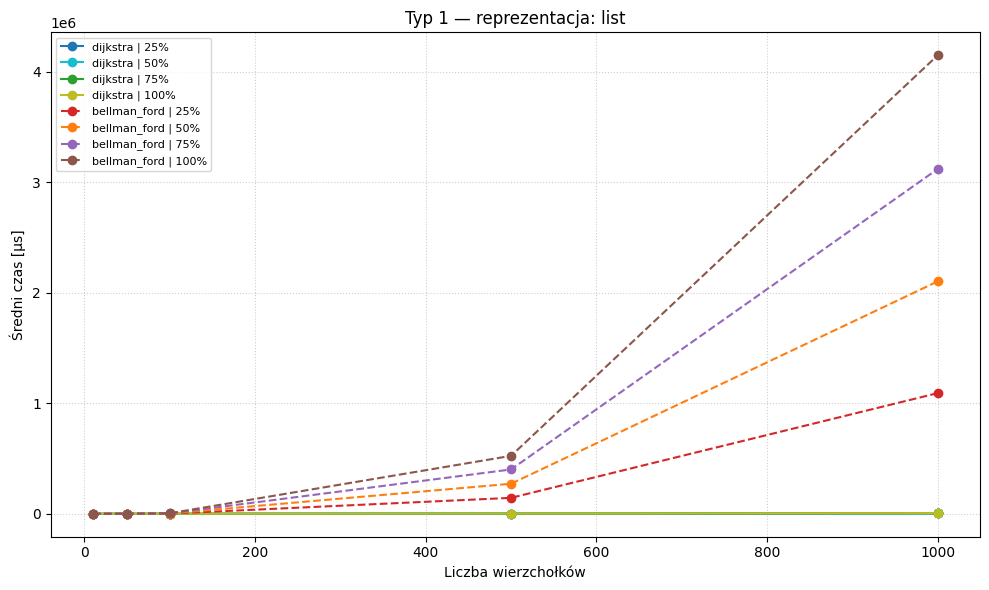

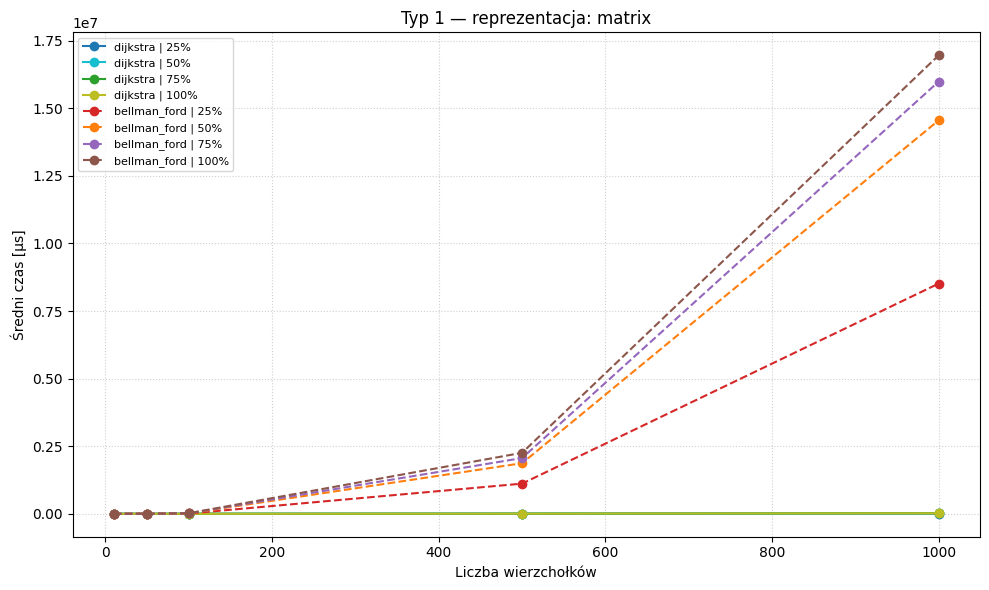

In [4]:
COLORS = {
    ('dijkstra',    25):  ('tab:blue',   '-'),
    ('dijkstra',    50):  ('tab:cyan',   '-'),
    ('dijkstra',    75):  ('tab:green',  '-'),
    ('dijkstra',   100):  ('tab:olive',  '-'),
    ('bellman_ford', 25): ('tab:red',    '--'),
    ('bellman_ford', 50): ('tab:orange', '--'),
    ('bellman_ford', 75): ('tab:purple', '--'),
    ('bellman_ford',100): ('tab:brown',  '--'),
}

for g_type in GRAPH_TYPES:
    fig, ax = plt.subplots(figsize=(10, 6))
    for algo in ALGOS:
        for d in DENSITIES:
            subset = df_all[
                (df_all.algo == algo) &
                (df_all.graph_type == g_type) &
                (df_all.density == d)
            ].sort_values('vertices')
            if subset.empty:
                continue
            color, ls = COLORS[(algo, d)]
            label = f'{algo} | {d}%'
            ax.plot(subset['vertices'], subset['avg_us'],
                    color=color, linestyle=ls, marker='o', label=label)

    ax.set_title(f'Typ 1 — reprezentacja: {g_type}')
    ax.set_xlabel('Liczba wierzchołków')
    ax.set_ylabel('Średni czas [µs]')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(DATA_DIR / f'typ1_{g_type}.png', dpi=150)
    plt.show()

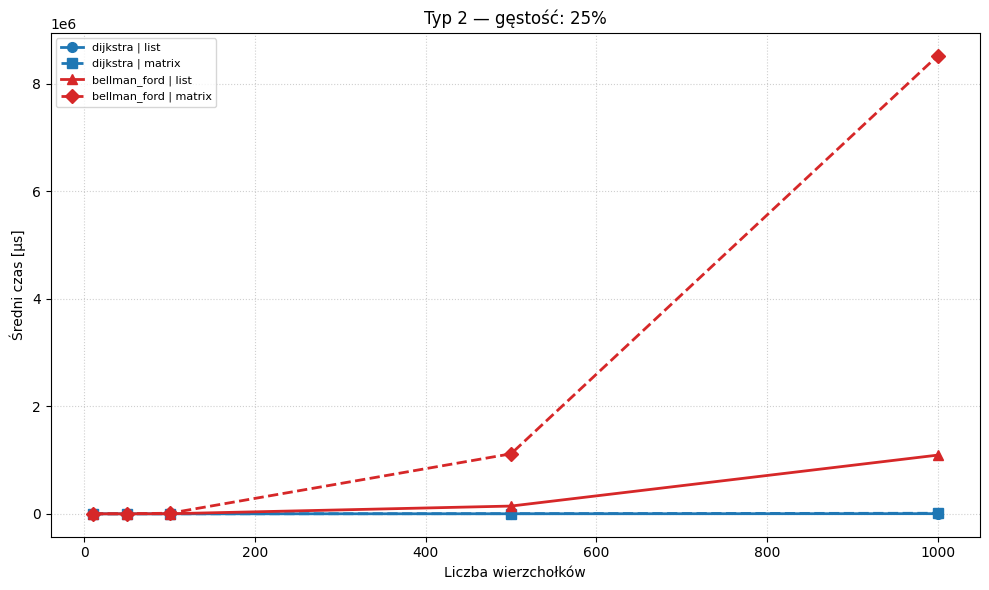

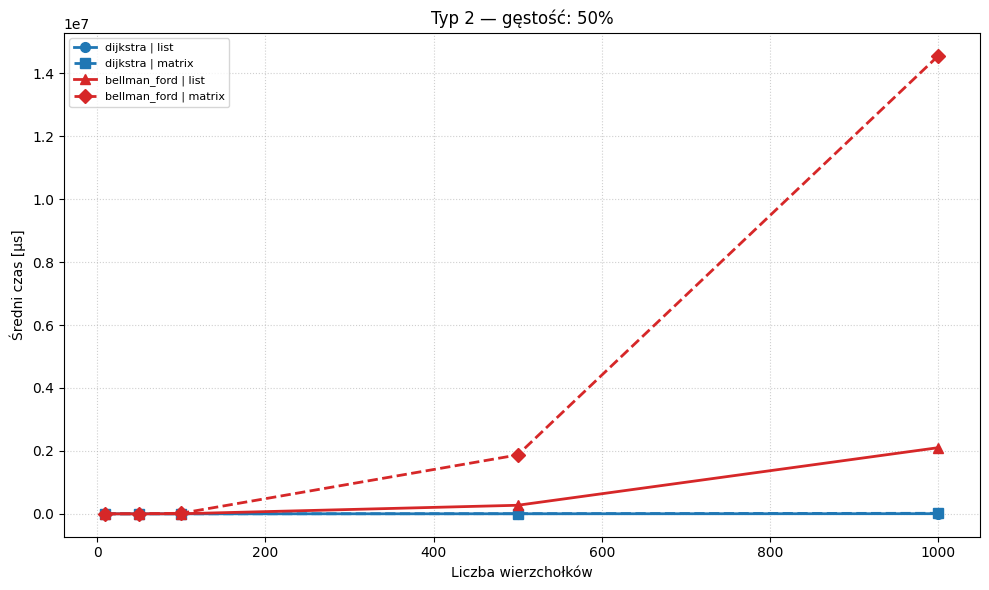

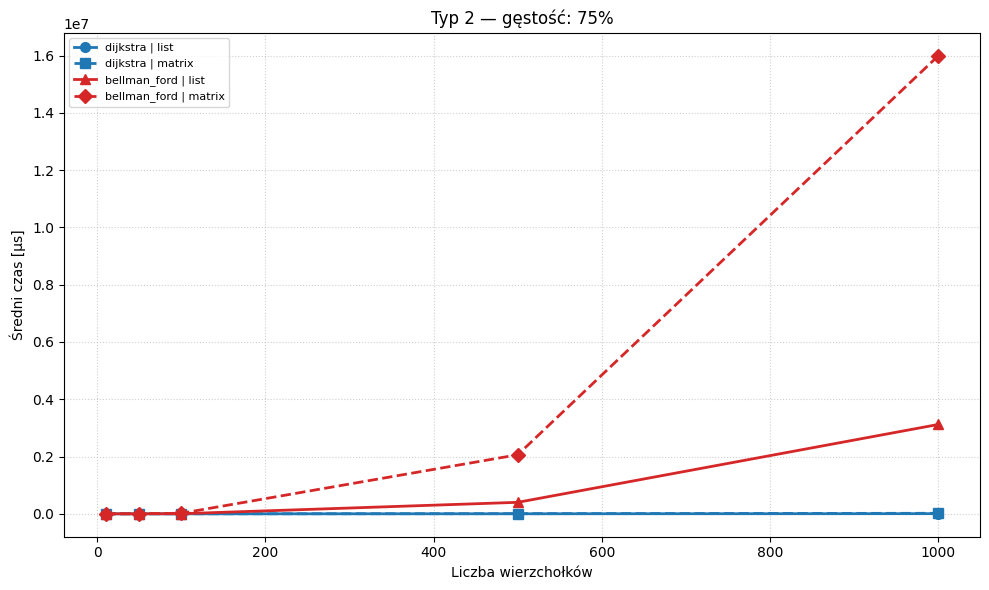

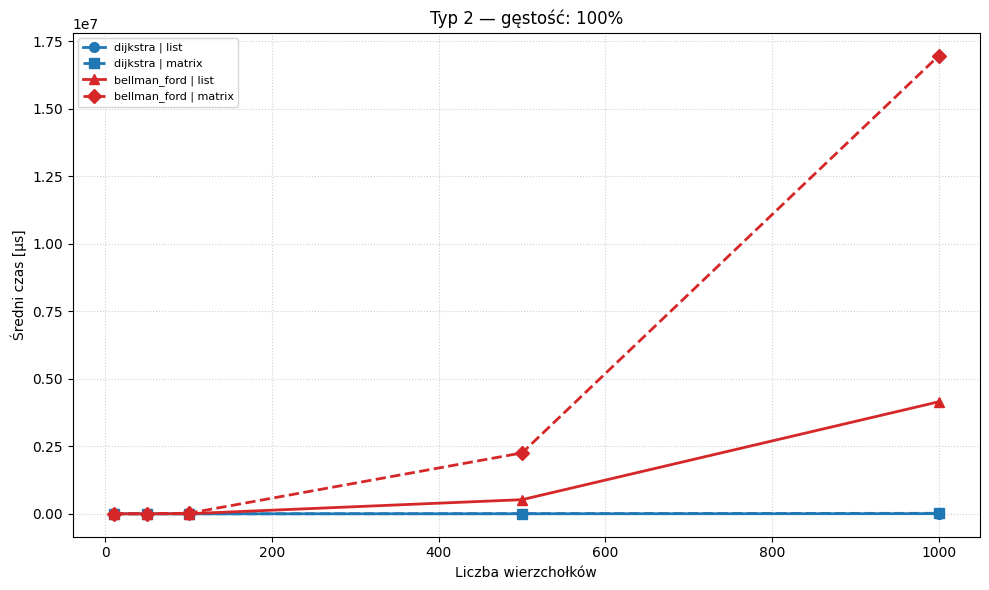

In [5]:
STYLE_TYPE2 = {
    ('dijkstra',    'list'):   ('tab:blue', '-',  'o', 2.0),
    ('dijkstra',    'matrix'): ('tab:blue', '--', 's', 2.0),
    ('bellman_ford','list'):   ('tab:red',  '-',  '^', 2.0),
    ('bellman_ford','matrix'): ('tab:red',  '--', 'D', 2.0),
}

# w pętli:
color, ls, marker, lw = STYLE_TYPE2[(algo, g_type)]
ax.plot(subset['vertices'], subset['avg_us'],
        color=color, linestyle=ls, marker=marker,
        linewidth=lw, markersize=7, label=label)

for d in DENSITIES:
    fig, ax = plt.subplots(figsize=(10, 6))
    for algo in ALGOS:
        for g_type in GRAPH_TYPES:
            subset = df_all[
                (df_all.algo == algo) &
                (df_all.graph_type == g_type) &
                (df_all.density == d)
            ].sort_values('vertices')
            if subset.empty:
                continue
            color, ls, marker, lw = STYLE_TYPE2[(algo, g_type)]
            label = f'{algo} | {g_type}'
            ax.plot(subset['vertices'], subset['avg_us'],
            color=color, linestyle=ls, marker=marker,
            linewidth=lw, markersize=7, label=label)

    ax.set_title(f'Typ 2 — gęstość: {d}%')
    ax.set_xlabel('Liczba wierzchołków')
    ax.set_ylabel('Średni czas [µs]')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(DATA_DIR / f'typ2_{d}.png', dpi=150)
    plt.show()

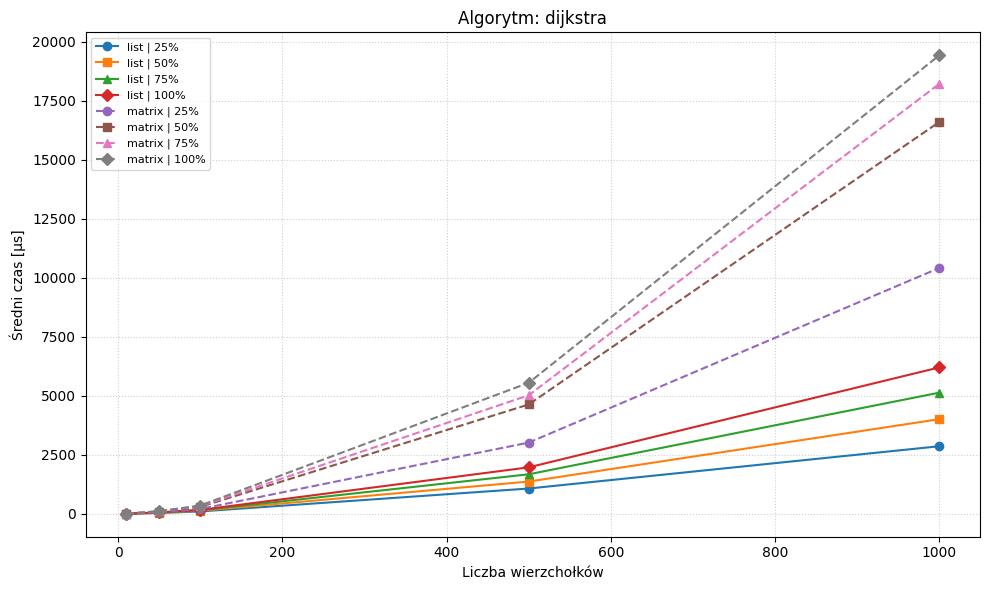

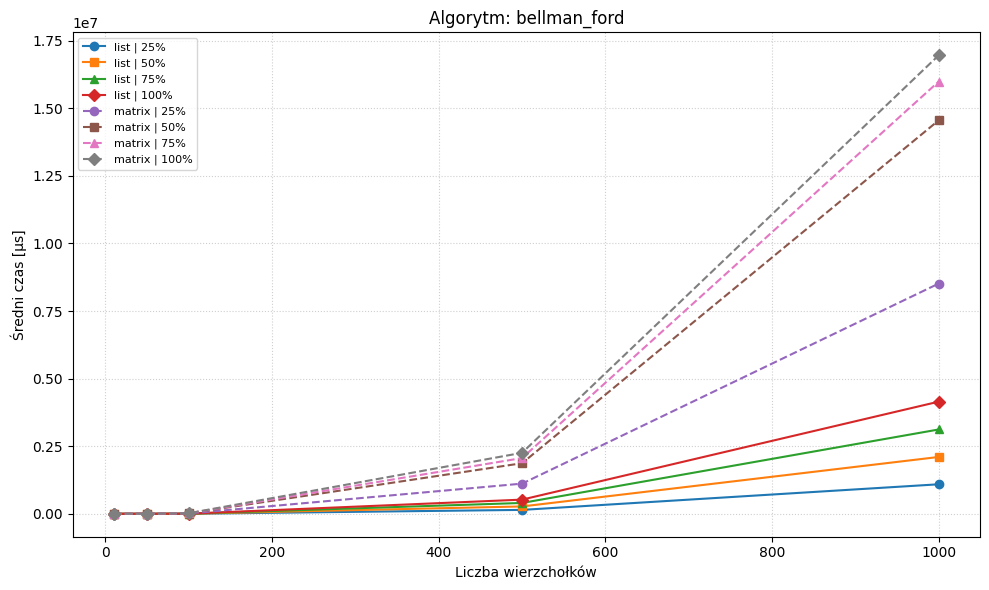

In [6]:
STYLE_ALGO = {
    ('list',    25):  ('tab:blue',    '-',   'o'),
    ('list',    50):  ('tab:orange',  '-',   's'),
    ('list',    75):  ('tab:green',   '-',   '^'),
    ('list',   100):  ('tab:red',     '-',   'D'),
    ('matrix',  25):  ('tab:purple',  '--',  'o'),
    ('matrix',  50):  ('tab:brown',   '--',  's'),
    ('matrix',  75):  ('tab:pink',    '--',  '^'),
    ('matrix', 100):  ('tab:gray',    '--',  'D'),
}

for algo in ALGOS:
    fig, ax = plt.subplots(figsize=(10, 6))
    for g_type in GRAPH_TYPES:
        for d in DENSITIES:
            subset = df_all[
                (df_all.algo == algo) &
                (df_all.graph_type == g_type) &
                (df_all.density == d)
            ].sort_values('vertices')
            if subset.empty:
                continue
            color, ls, marker = STYLE_ALGO[(g_type, d)]
            label = f'{g_type} | {d}%'
            ax.plot(subset['vertices'], subset['avg_us'],
                    color=color, linestyle=ls, marker=marker, label=label)

    ax.set_title(f'Algorytm: {algo}')
    ax.set_xlabel('Liczba wierzchołków')
    ax.set_ylabel('Średni czas [µs]')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(DATA_DIR / f'algo_{algo}.png', dpi=150)
    plt.show()